# Lab Assignment 4 NLP

**Title:** NLP Preprocessing and Text Classification

Natural Language Processing for Sentiment Analysis of E-commerce Reviews

**Name:** Atharva Suryawanshi
**PRN:** 202301040283
**AIML Batch:** 3

## 1. Import Libraries

In [12]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

## 2. Download NLTK Data

NLTK (Natural Language Toolkit) is used for tasks like stopword removal and lemmatization. We download the necessary data packages here.

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

## 3. Load Dataset

In this section, we'll load the Amazon product reviews dataset. We'll use `kagglehub` to download the dataset and then load it into a pandas DataFrame.

In [ ]:
!pip install kagglehub


In [ ]:
import kagglehub

path = kagglehub.dataset_download("arhamrumi/amazon-product-reviews")

print("Path to dataset files:", path)

100%|██████████| 115M/115M [00:00<00:00, 172MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arhamrumi/amazon-product-reviews/versions/1


In [ ]:
import os

files = os.listdir(path)
print(files)

['Reviews.csv']


In [ ]:
df = pd.read_csv(os.path.join(path, "Reviews.csv"))

In [16]:
df = df.rename(columns={
    'Text': 'reviewText',
    'Score': 'overall'
})



In [18]:
f = df[['reviewText', 'overall']]
df = df.dropna()

df.head()

KeyError: "['overall'] not in index"

In [19]:
df = df.sample(10000, random_state=42)

## 4. Sentiment Conversion

To prepare the data for sentiment analysis, we convert the numerical `overall` ratings into categorical sentiment labels: 'positive', 'neutral', and 'negative'. Ratings of 4 or 5 are 'positive', 3 is 'neutral', and 1 or 2 are 'negative'.

In [20]:
def get_sentiment(rating):
    if rating >= 4:
        return "positive"
    elif rating == 3:
        return "neutral"
    else:
        return "negative"

df['sentiment'] = df['overall'].apply(get_sentiment)

df = df[['reviewText', 'sentiment']]
df = df.dropna()

KeyError: 'overall'

## 5. NLP Preprocessing

This section handles text preprocessing, a crucial step for preparing text data for machine learning models. The preprocessing steps include:

- **Tokenization:** Breaking down text into individual words.
- **Stopword Removal:** Eliminating common words (e.g., 'the', 'a', 'is') that don't carry significant meaning.
- **Stemming:** Reducing words to their root form (e.g., 'running' to 'run').
- **Lemmatization:** Converting words to their base form, considering vocabulary and morphological analysis (e.g., 'better' to 'good').

These steps help normalize the text data, reduce dimensionality, and improve the performance of our models.

In [21]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)

    words = text.split()
    words = [w for w in words if w not in stop_words]

    words = [stemmer.stem(w) for w in words]
    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

df['clean_text'] = df['reviewText'].apply(preprocess)

## 6. Train-Test Split

We split the preprocessed data into training and testing sets. The training set is used to train our models, and the testing set is used to evaluate their performance on unseen data. A standard 80/20 split is used, with 80% for training and 20% for testing.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['sentiment'], test_size=0.2, random_state=42
)

## 7. CountVectorizer

**CountVectorizer** converts a collection of text documents to a matrix of token counts. It's a simple yet effective way to represent text data numerically, where each word's frequency is considered a feature. We limit the features to the top 5000 most frequent words.

In [23]:
cv = CountVectorizer(max_features=5000)

X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

## 8. Naive Bayes Model

Here, we train a **Multinomial Naive Bayes** classifier on the CountVectorizer transformed training data. Naive Bayes is a probabilistic classifier based on Bayes' theorem, commonly used for text classification tasks due to its simplicity and effectiveness.

In [24]:
nb = MultinomialNB()
nb.fit(X_train_cv, y_train)

y_pred_nb = nb.predict(X_test_cv)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8085
              precision    recall  f1-score   support

    negative       0.58      0.54      0.56       296
     neutral       0.31      0.19      0.23       150
    positive       0.88      0.92      0.90      1554

    accuracy                           0.81      2000
   macro avg       0.59      0.55      0.56      2000
weighted avg       0.79      0.81      0.80      2000



## 9. TF-IDF Vectorization

**TF-IDF (Term Frequency-Inverse Document Frequency)** is another method for converting text into numerical representations. Unlike CountVectorizer, TF-IDF assigns weights to words based on their importance in a document relative to the entire corpus. Words that are common in a document but rare across all documents get higher scores, capturing more meaningful terms. We use `max_features=5000` and `ngram_range=(1,2)` to include both single words and two-word phrases.

In [25]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## 10. Logistic Regression

We apply **Logistic Regression**, a linear model for classification, to the TF-IDF transformed data. Despite its name, Logistic Regression is a classification algorithm that models the probability of a binary outcome, which can be extended for multi-class classification.

In [26]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.83
              precision    recall  f1-score   support

    negative       0.76      0.41      0.53       296
     neutral       0.50      0.03      0.06       150
    positive       0.84      0.99      0.91      1554

    accuracy                           0.83      2000
   macro avg       0.70      0.48      0.50      2000
weighted avg       0.80      0.83      0.79      2000



## 11. Support Vector Machine (SVM)

This section implements a **Linear Support Vector Machine (SVM)** classifier using the TF-IDF features. SVMs are powerful classification models that aim to find the optimal hyperplane to separate data points into different classes, maximizing the margin between them.

In [27]:
svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.826


## 12. Confusion Matrix

A **Confusion Matrix** is a performance measurement for machine learning classification. It visualizes the performance of an algorithm, allowing us to see how many predictions were correct and incorrect for each class. Here, we generate one for the Logistic Regression model.

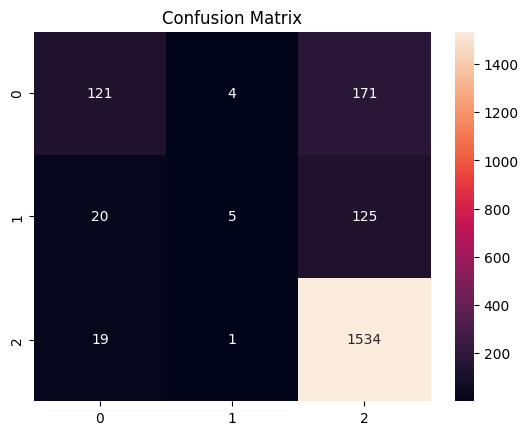

In [28]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

## 13. Model Comparison and Evaluation

This section compares the performance of the trained models (Naive Bayes, Logistic Regression, and SVM) based on their accuracy scores. A bar chart is generated to visually represent the accuracies, providing a clear comparison of which model performs best for this sentiment analysis task. Additional metrics like precision, recall, and F1-score are also presented for a more detailed evaluation of the Logistic Regression model.

Naive Bayes (CV): 0.8085
Logistic Regression (TF-IDF): 0.83
SVM (TF-IDF): 0.826


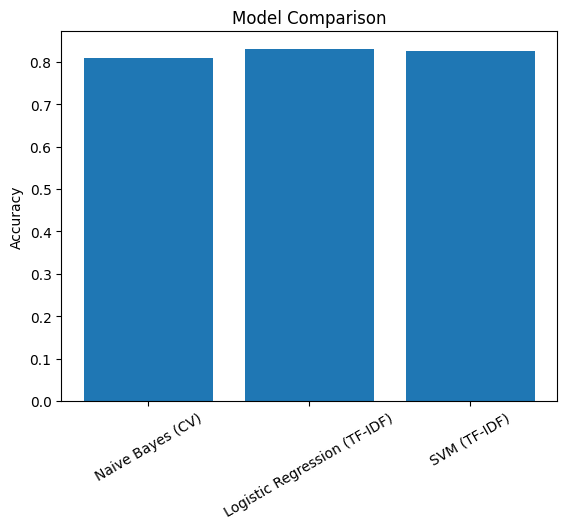

Precision: 0.8007463114754099
Recall: 0.83
F1 Score: 0.7876746220604703


In [34]:
results = {
    "Naive Bayes (CV)": accuracy_score(y_test, y_pred_nb),
    "Logistic Regression (TF-IDF)": accuracy_score(y_test, y_pred_lr),
    "SVM (TF-IDF)": accuracy_score(y_test, y_pred_svm)
}

for model, acc in results.items():
    print(f"{model}: {acc}")
plt.bar(results.keys(), results.values())
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()


from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred_lr, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_lr, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_lr, average='weighted'))

## 14. Prediction Function

This function allows us to predict the sentiment of a new, unseen review. It applies the same preprocessing steps as the training phase (cleaning, tokenization, stopword removal, stemming, and lemmatization) and then uses the best-performing model (Logistic Regression with TF-IDF) to classify the sentiment.

In [30]:
def predict_review(text):
    text = preprocess(text)
    vec = tfidf.transform([text])
    return lr.predict(vec)[0]

print(predict_review("This product is amazing"))

positive


In [33]:
print("===== Detailed Evaluation (Logistic Regression) =====")
print(classification_report(y_test, y_pred_lr))

===== Detailed Evaluation (Logistic Regression) =====
              precision    recall  f1-score   support

    negative       0.76      0.41      0.53       296
     neutral       0.50      0.03      0.06       150
    positive       0.84      0.99      0.91      1554

    accuracy                           0.83      2000
   macro avg       0.70      0.48      0.50      2000
weighted avg       0.80      0.83      0.79      2000

